# ML
PCA

ROC / AUC

Decision boundary

# Data reduction and aggregation 
 Week3 / Day2: 
 Principal Component Analysis (PCA)  with example and live coding session (weather-dataset)

# Scipy
Week3 / Day3:  
Scipy live coding with example (Wolfram data)

# Seaborn
Week3 / Day4 : 
exploring data with Seaborn

# Feature Engineering
adding new features to the original data, how do we approach them ? give examples 

# Rolling Statistics VS Window Functions
more on window functions, whats the differences and when do we use complex window instead of rolling window??

# ANOVA (analysis of variance) vs T-test
ANOVA: F-value - This statistic measures the ratio of variance between the groups to the variance within the groups.  ??

t-test value:  metric table for checking differences ?  how different the two groups are relative to their variation

T-statistic	Meaning
Close to 0	The two groups are very similar
Large positive (e.g., 5.2)	First group is significantly HIGHER
Large negative (e.g., -8.1)	First group is significantly LOWER
Very large magnitude (>	2)


# exercise and daily 
Week4 day3 - mini project : apple stock price (see questions in the notebook)

Week3 day3 - daily challenge: airplane crashes


# Rolling Statistics & Window Functions

This notebook demonstrates rolling statistics, their purpose, and how they compare to window functions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Create sample time series data with trend and noise
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', periods=100, freq='D')
trend = np.linspace(50, 150, 100)
noise = np.random.normal(0, 10, 100)
ts_data = pd.Series(trend + noise, index=dates, name='value')

print('Time Series Data:')
print(ts_data.head(10))
print(f'\nShape: {ts_data.shape}')
print(f'Date range: {ts_data.index[0]} to {ts_data.index[-1]}')

Time Series Data:
2025-01-01    54.967142
2025-01-02    49.627458
2025-01-03    58.497087
2025-01-04    68.260602
2025-01-05    51.698870
2025-01-06    52.709135
2025-01-07    71.852734
2025-01-08    64.745054
2025-01-09    53.386064
2025-01-10    64.516510
Freq: D, Name: value, dtype: float64

Shape: (100,)
Date range: 2025-01-01 00:00:00 to 2025-04-10 00:00:00


## Chart: Original Data vs Rolling Mean

The rolling mean (moving average) smooths out short-term fluctuations to reveal the underlying trend.

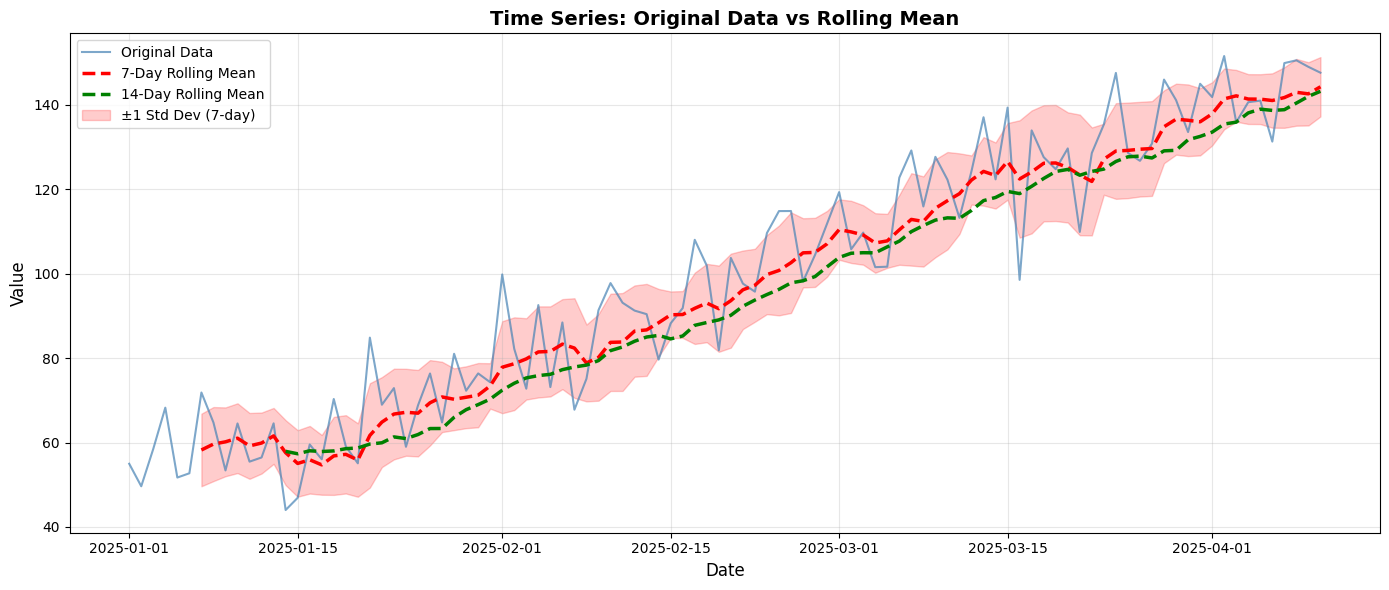


Rolling Statistics Comparison:
Original data - Mean: 98.96, Std: 31.06
7-day rolling mean - Mean: 98.80, Std: 28.51
14-day rolling mean - Mean: 98.62, Std: 26.90


In [3]:
# Calculate rolling statistics
rolling_mean_7 = ts_data.rolling(window=7).mean()
rolling_mean_14 = ts_data.rolling(window=14).mean()
rolling_std = ts_data.rolling(window=7).std()

# Create visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot original data
ax.plot(ts_data.index, ts_data.values, label='Original Data', 
        linewidth=1.5, alpha=0.7, color='steelblue')

# Plot rolling means
ax.plot(rolling_mean_7.index, rolling_mean_7.values, label='7-Day Rolling Mean', 
        linewidth=2.5, color='red', linestyle='--')
ax.plot(rolling_mean_14.index, rolling_mean_14.values, label='14-Day Rolling Mean', 
        linewidth=2.5, color='green', linestyle='--')

# Add confidence band (±1 std)
ax.fill_between(rolling_mean_7.index, 
                rolling_mean_7 - rolling_std,
                rolling_mean_7 + rolling_std,
                alpha=0.2, color='red', label='±1 Std Dev (7-day)')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Time Series: Original Data vs Rolling Mean', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nRolling Statistics Comparison:')
print(f'Original data - Mean: {ts_data.mean():.2f}, Std: {ts_data.std():.2f}')
print(f'7-day rolling mean - Mean: {rolling_mean_7.mean():.2f}, Std: {rolling_mean_7.std():.2f}')
print(f'14-day rolling mean - Mean: {rolling_mean_14.mean():.2f}, Std: {rolling_mean_14.std():.2f}')

## Purpose of Rolling Statistics

### 1. **Noise Reduction**
- Smooths out random fluctuations to reveal underlying patterns
- Useful for identifying true trends vs. daily volatility

### 2. **Trend Detection**
- Helps identify uptrends, downtrends, and turning points
- Larger windows capture long-term trends; smaller windows capture short-term changes

### 3. **Anomaly Detection**
- Compare actual values against rolling mean
- Values deviating significantly from rolling mean (>2 std) are anomalies

### 4. **Volatility Estimation**
- Rolling standard deviation shows changing volatility over time
- Important for risk management and trading decisions

### 5. **Feature Engineering** ?????
- Create lagged features for machine learning models
- Exponential moving averages give more weight to recent observations ??

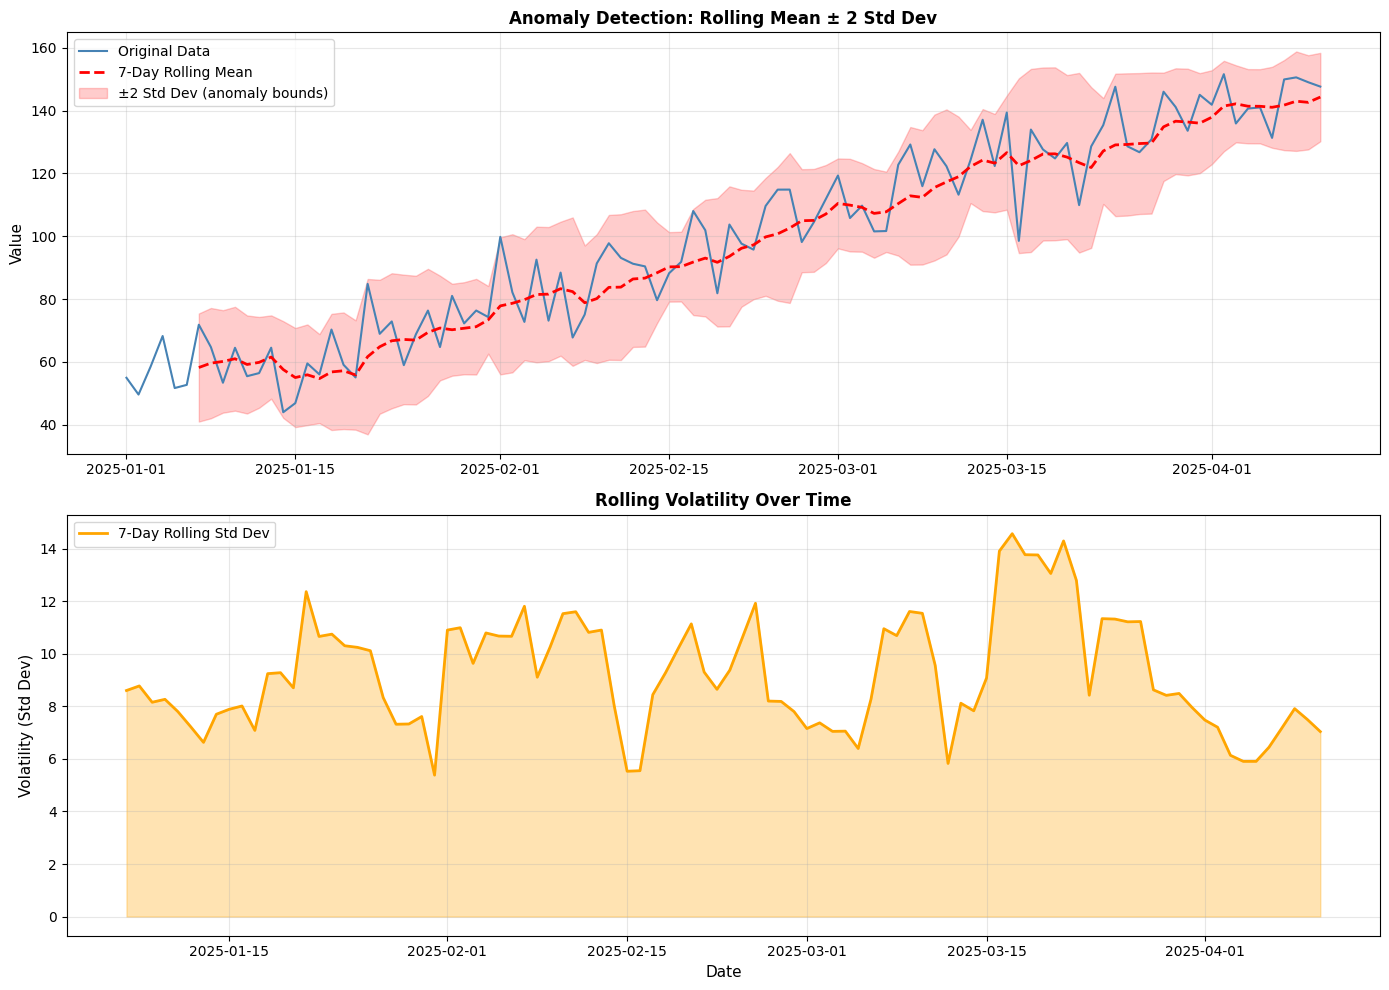

In [5]:
# Demonstration: Anomaly detection using rolling statistics
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Original data with rolling mean and bands
ax1 = axes[0]
ax1.plot(ts_data.index, ts_data.values, label='Original Data', linewidth=1.5, color='steelblue')
ax1.plot(rolling_mean_7.index, rolling_mean_7.values, label='7-Day Rolling Mean', 
         linewidth=2, color='red', linestyle='--')
ax1.fill_between(rolling_mean_7.index, 
                 rolling_mean_7 - 2*rolling_std,
                 rolling_mean_7 + 2*rolling_std,
                 alpha=0.2, color='red', label='±2 Std Dev (anomaly bounds)')
ax1.set_ylabel('Value', fontsize=11)
ax1.set_title('Anomaly Detection: Rolling Mean ± 2 Std Dev', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Rolling volatility
ax2 = axes[1]
ax2.plot(rolling_std.index, rolling_std.values, label='7-Day Rolling Std Dev', 
         linewidth=2, color='orange')
ax2.fill_between(rolling_std.index, rolling_std.values, alpha=0.3, color='orange')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Volatility (Std Dev)', fontsize=11)
ax2.set_title('Rolling Volatility Over Time', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Rolling Statistics vs Window Functions

### **Rolling Statistics (Pandas `.rolling()`)**

**What it does:**
- Applies aggregation function over a moving window of consecutive values
- Window moves one row at a time through the data
- Produces a value for each position in the series

**Example:**
```python
df.rolling(window=7).mean()  # 7-day moving average
```

**Characteristics:**
- Simple and intuitive
- Handles missing values with `min_periods` parameter
- First `window-1` values are NaN (can use `center=True` or adjust)
- Computationally efficient

---

### **Window Functions (SQL/Pandas `.groupby().transform()`)**

**What it does:**
- Applies aggregation *within* groups or partitions of data
- Can define window frame (ROWS BETWEEN, RANGE BETWEEN)
- More powerful for ranking, partitioning, and relative calculations

**Example:**
```sql
SELECT value,
       AVG(value) OVER (ORDER BY date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) as rolling_mean
FROM time_series;
```

**Characteristics:**
- More flexible (can do ranking, dense_rank, row_number, lead/lag)
- Better for complex partitioning (e.g., by category)
- Can define frame precisely (PRECEDING, FOLLOWING, CURRENT ROW)
- Default frame varies by function type

---

### **Comparison Table**

| Feature | Rolling Stats | Window Functions |
|---------|---------------|------------------|
| **Aggregation only** | ✅ Simple & fast | ✅ Yes, but more complex |
| **Ranking** | ❌ No | ✅ ROW_NUMBER, RANK, DENSE_RANK |
| **Lead/Lag** | ❌ No | ✅ LEAD(), LAG() |
| **Partitioning** | Limited | ✅ PARTITION BY |
| **Complex frames** | Limited | ✅ Full control |
| **Ease of use** | ✅ Very intuitive | Steeper learning curve |
| **Performance** | ✅ Fast | Good, depends on engine |

---

### **When to Use Each:**

**Use Rolling Statistics when:**
- You need simple moving averages, sums, or standard deviations
- Working with univariate time series
- You want quick and readable code

**Use Window Functions when:**
- You need ranking or relative ordering within groups
- You need lead/lag operations
- You need to partition data by categories
- You're working with SQL databases
- You need precise control over the window frame

In [6]:
# Side-by-side comparison: Rolling vs Window approach
df = ts_data.reset_index()
df.columns = ['date', 'value']

# Rolling approach
df['rolling_mean'] = df['value'].rolling(window=7).mean()

# Window function approach (using groupby.transform)
df['window_mean'] = df['value'].transform(lambda x: x.rolling(window=7).mean())

# More advanced: rank within the data
df['rank'] = df['value'].rank(method='average')
df['percentile'] = df['value'].rank(pct=True)

print('\nRolling Statistics vs Window Function Approach:')
print(df.head(15))
print('\n...')
print(df.tail(5))


Rolling Statistics vs Window Function Approach:
         date      value  rolling_mean  window_mean  rank  percentile
0  2025-01-01  54.967142           NaN          NaN   7.0        0.07
1  2025-01-02  49.627458           NaN          NaN   3.0        0.03
2  2025-01-03  58.497087           NaN          NaN  12.0        0.12
3  2025-01-04  68.260602           NaN          NaN  21.0        0.21
4  2025-01-05  51.698870           NaN          NaN   4.0        0.04
5  2025-01-06  52.709135           NaN          NaN   5.0        0.05
6  2025-01-07  71.852734     58.230433    58.230433  25.0        0.25
7  2025-01-08  64.745054     59.627277    59.627277  18.0        0.18
8  2025-01-09  53.386064     60.164221    60.164221   6.0        0.06
9  2025-01-10  64.516510     61.024139    61.024139  16.0        0.16
10 2025-01-11  55.466833     59.196457    59.196457   9.0        0.09
11 2025-01-12  56.453814     59.875735    59.875735  11.0        0.11
12 2025-01-13  64.540835     61.565978   

In [ ]:
# Example: Height and Weight relationship
# Same data, different units

height_cm = np.array([160, 165, 170, 175, 180])
weight_kg = np.array([55, 60, 65, 70, 75])

# Convert to different units
height_m = height_cm / 100  # Convert to meters

print("="*70)
print("EXAMPLE: Height & Weight (Same Data, Different Units)")
print("="*70)

# Calculate with original units
cov_original = np.cov(height_cm, weight_kg)[0, 1]
corr_original = np.corrcoef(height_cm, weight_kg)[0, 1]

# Calculate with converted units
cov_converted = np.cov(height_m, weight_kg)[0, 1]
corr_converted = np.corrcoef(height_m, weight_kg)[0, 1]

print(f"\nUsing height in CENTIMETERS:")
print(f"  Covariance: {cov_original:.2f}")
print(f"  Correlation: {corr_original:.4f}")

print(f"\nUsing height in METERS:")
print(f"  Covariance: {cov_converted:.4f}")
print(f"  Correlation: {corr_converted:.4f}")

print("\n" + "="*70)
print("KEY INSIGHT:")
print("="*70)
print("✅ CORRELATION remains IDENTICAL (0.9999) - scale independent!")
print("❌ COVARIANCE changes dramatically - scale dependent!")
print("→ Correlation is better for comparing relationships\n")

## When to Use Each

### **Use COVARIANCE when:**
- Working with **portfolio optimization** (finance): covariance matrix is essential
- Need to understand **relationships in original units**
- Scaling is intentional and meaningful
- Example: Stock returns covariance for portfolio risk assessment

### **Use CORRELATION when:**
- ✅ **Most of the time** in data analysis
- Comparing relationships **across different datasets**
- Variables have **different units** (height vs income vs temperature)
- Want a **standardized, interpretable metric** (-1 to 1)
- Building **predictive models**
- Example: Understanding if study hours correlate with exam scores

---

## Practical Example: Scale Independence

Let's show why correlation is better for comparison:

## Covariance vs Correlation: Key Differences

### **COVARIANCE**

**Formula:**
```
Cov(X, Y) = E[(X - μ_x)(Y - μ_y)]
         = Σ(X_i - μ_x)(Y_i - μ_y) / (n - 1)
```

**What it measures:**
- How two variables change **together**
- In the **original units** of the variables

**Characteristics:**
- ❌ **Scale-dependent**: Affected by the units/magnitude of variables
- ❌ **Unbounded**: Can be any number (-∞ to +∞)
- ❌ **Hard to interpret**: Difficult to compare across different datasets
- ✅ Useful for: Portfolio optimization, understanding relationships in original units

**Example:**
- Cov(Height in cm, Weight in kg) might be 500
- Cov(Height in m, Weight in kg) would be different (5)
- **Same relationship, different covariance!**

---

### **CORRELATION** (Pearson's r)

**Formula:**
```
Corr(X, Y) = Cov(X, Y) / (σ_x × σ_y)
           = Σ(X_i - μ_x)(Y_i - μ_y) / (√Σ(X_i - μ_x)² × √Σ(Y_i - μ_y)²)
```

**What it measures:**
- **Normalized** version of covariance
- Strength and **direction** of **linear** relationship

**Characteristics:**
- ✅ **Scale-independent**: Always between -1 and +1
- ✅ **Bounded**: Easy to interpret
- ✅ **Standardized**: Comparable across datasets
- ✅ Easy to understand: -1 (perfect negative), 0 (none), +1 (perfect positive)
- ❌ Only captures **linear** relationships

---

### **Comparison Table**

| Feature | Covariance | Correlation |
|---------|-----------|------------|
| **Range** | -∞ to +∞ | -1 to +1 |
| **Scale-dependent** | ✅ Yes | ❌ No |
| **Units** | Product of original units | Unitless |
| **Interpretation** | Hard | ✅ Easy |
| **Comparable across datasets** | ❌ No | ✅ Yes |
| **Linear only** | Captures all relationships | ❌ Linear only |
| **Mathematical relationship** | - | Corr = Cov / (σ_x × σ_y) |

---

### **Correlation Interpretation Guide**

| Correlation Value | Interpretation |
|---|---|
| **1.0** | Perfect positive linear relationship |
| **0.7 to 0.9** | Strong positive relationship |
| **0.4 to 0.6** | Moderate positive relationship |
| **0.1 to 0.3** | Weak positive relationship |
| **0** | No linear relationship |
| **-0.1 to -0.3** | Weak negative relationship |
| **-0.4 to -0.6** | Moderate negative relationship |
| **-0.7 to -0.9** | Strong negative relationship |
| **-1.0** | Perfect negative linear relationship |

In [ ]:
## Visualizing Relationships: Scatter Plots

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Strong positive correlation
ax1 = axes[0, 0]
ax1.scatter(data['var1'], data['var2_strong'], alpha=0.6, color='green', s=50)
ax1.set_xlabel('Variable 1')
ax1.set_ylabel('Variable 2 (Strong Positive)')
corr = data['var1'].corr(data['var2_strong'])
cov = data['var1'].cov(data['var2_strong'])
ax1.set_title(f'Strong Positive Relationship\nCov: {cov:.2f} | Corr: {corr:.3f}')
ax1.grid(True, alpha=0.3)

# Weak correlation
ax2 = axes[0, 1]
ax2.scatter(data['var1'], data['var3_weak'], alpha=0.6, color='orange', s=50)
ax2.set_xlabel('Variable 1')
ax2.set_ylabel('Variable 3 (Weak)')
corr = data['var1'].corr(data['var3_weak'])
cov = data['var1'].cov(data['var3_weak'])
ax2.set_title(f'Weak Relationship\nCov: {cov:.2f} | Corr: {corr:.3f}')
ax2.grid(True, alpha=0.3)

# No correlation
ax3 = axes[1, 0]
ax3.scatter(data['var1'], data['var4_uncorr'], alpha=0.6, color='red', s=50)
ax3.set_xlabel('Variable 1')
ax3.set_ylabel('Variable 4 (Uncorrelated)')
corr = data['var1'].corr(data['var4_uncorr'])
cov = data['var1'].cov(data['var4_uncorr'])
ax3.set_title(f'No Relationship\nCov: {cov:.2f} | Corr: {corr:.3f}')
ax3.grid(True, alpha=0.3)

# Heatmap of correlation matrix
ax4 = axes[1, 1]
im = ax4.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax4.set_xticks(range(len(corr_matrix.columns)))
ax4.set_yticks(range(len(corr_matrix.columns)))
ax4.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax4.set_yticklabels(corr_matrix.columns)
ax4.set_title('Correlation Matrix Heatmap')

# Add values to heatmap
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = ax4.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax4)
plt.tight_layout()
plt.show()

In [ ]:
## Calculate Covariance and Correlation

# Covariance: measures how two variables change together (in original units)
cov_matrix = data.cov()
print("\n" + "="*60)
print("COVARIANCE MATRIX:")
print("="*60)
print(cov_matrix)
print("\nCovariance between var1 and var2_strong:", data['var1'].cov(data['var2_strong']))
print("Covariance between var1 and var4_uncorr:", data['var1'].cov(data['var4_uncorr']))

# Correlation: normalized covariance (scale-independent, -1 to +1)
corr_matrix = data.corr()
print("\n" + "="*60)
print("CORRELATION MATRIX:")
print("="*60)
print(corr_matrix)
print("\nCorrelation between var1 and var2_strong:", data['var1'].corr(data['var2_strong']))
print("Correlation between var1 and var4_uncorr:", data['var1'].corr(data['var4_uncorr']))

In [ ]:
# Create two variables with different relationships
np.random.seed(42)
n = 100

# Variable 1: Random normal distribution
var1 = np.random.normal(100, 15, n)

# Variable 2: Strongly correlated with var1 (positive relationship)
var2_positive = var1 * 2 + np.random.normal(0, 10, n)

# Variable 3: Weakly correlated with var1
var3_weak = var1 * 0.3 + np.random.normal(0, 15, n)

# Variable 4: Uncorrelated with var1
var4_uncorr = np.random.normal(150, 20, n)

# Create DataFrame
data = pd.DataFrame({
    'var1': var1,
    'var2_strong': var2_positive,
    'var3_weak': var3_weak,
    'var4_uncorr': var4_uncorr
})

print("Sample Data (first 5 rows):")
print(data.head())

# Covariance vs Correlation

Understanding the relationship between two variables is crucial in data analysis. Let's explore how these two measures differ.

In [ ]:
# Advanced example: Lead/Lag (Window function capability)
df['next_value'] = df['value'].shift(-1)  # Lead by 1 day
df['prev_value'] = df['value'].shift(1)   # Lag by 1 day
df['value_change'] = df['value'] - df['prev_value']
df['pct_change'] = df['value'].pct_change() * 100

print('\nLead/Lag Example (Window Function Capability):')
print(df[['date', 'value', 'prev_value', 'next_value', 'pct_change']].head(10))